# Projet NLP : Classification Thématique d'Articles de Presse
**NOM:** Mouad Karma

**Dataset :** BBC News

###  Objectif du Projet
Ce carnet Jupyter regroupe l'intégralité du pipeline de classification de textes pour notre projet de NLP. L'objectif est de comparer les performances de trois paradigmes distincts :
1. **Machine Learning Classique sur Matrices Creuses** (BoW, TF-IDF + Sélection de caractéristiques).
2. **Machine Learning sur Embeddings Denses** (Word2Vec, BERT).
3. **Deep Learning** (CNN 1D et LSTM).

## 1. Importation des Librairies et Chargement des Données


In [2]:
# ==========================================
# 1. LIBRAIRIES STANDARDS & CONFIGURATION
# ==========================================
import re
import string
import time
import warnings
from IPython.display import display

# Désactivation des messages d'avertissement pour un affichage propre
warnings.filterwarnings('ignore')

# ==========================================
# 2. MANIPULATION DE DONNÉES & VISUALISATION
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. NLP & REPRÉSENTATION TEXTUELLE
# ==========================================
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

# ==========================================
# 4. MACHINE LEARNING (SCIKIT-LEARN)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.decomposition import LatentDirichletAllocation

# Modèles ML
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Métriques d'évaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# 5. DEEP LEARNING (TENSORFLOW / KERAS)
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 2. Prétraitement du Texte (Text Cleaning et Représentation Vectorielle Creuse (BoW & TF-IDF & Word2VEc & BERT)


In [3]:


# Téléchargement des mots vides (quiet=True pour ne pas spammer la console)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))


def clean_text(text):
    """Nettoie le texte : minuscules, ponctuation et stopwords."""
    text = str(text).lower()
    # Enlever la ponctuation et les chiffres
    text = re.sub(f"[{re.escape(string.punctuation)}0-9]", " ", text)
    # Enlever les stopwords et les mots trop courts
    words = text.split()
    clean_words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(clean_words)




def apply_bow(text_series, max_features=1500):
    """
    Applique la vectorisation Bag of Words (BoW).
    Retourne la matrice transformée et le vectorizer.
    """
    vectorizer = CountVectorizer(max_features=max_features)
    X_bow = vectorizer.fit_transform(text_series)
    return X_bow, vectorizer





def apply_tfidf(text_series, max_features=1500):
    """
    Applique la vectorisation TF-IDF.
    Retourne la matrice transformée et le vectorizer.
    """
    vectorizer = TfidfVectorizer(max_features=max_features)
    X_tfidf = vectorizer.fit_transform(text_series)
    return X_tfidf, vectorizer





def apply_word2vec(text_series, vector_size=100, window=5, min_count=1):
    """
    Applique la vectorisation Word2Vec.
    Retourne les vecteurs moyens pour chaque document.
    """
    # Tokeniser les textes
    tokenized_texts = [text.split() for text in text_series]
    # Entraîner le modèle Word2Vec
    model = Word2Vec(sentences=tokenized_texts, vector_size=vector_size, window=window, min_count=min_count)
    # Obtenir les vecteurs moyens pour chaque document
    X_word2vec = []
    for tokens in tokenized_texts:
        word_vectors = [model.wv[word] for word in tokens if word in model.wv]
        if word_vectors:
            X_word2vec.append(np.mean(word_vectors, axis=0))
        else:
            X_word2vec.append(np.zeros(vector_size))
    return np.array(X_word2vec), model





def apply_bert(text_series, model_name='all-MiniLM-L6-v2'):
    """
    Applique la vectorisation avec un modèle type BERT (Sentence Transformers).
    Retourne la matrice des embeddings pour chaque document.

    'all-MiniLM-L6-v2' est une version légère et très rapide de BERT,
    parfaite pour extraire des features pour le Machine Learning.
    """
    print(f"Chargement du modèle BERT ({model_name})... Cela peut prendre quelques secondes.")
    model = SentenceTransformer(model_name)

    print("Encodage des textes avec BERT en cours...")
    # L'encodage transforme la liste de textes en une matrice numpy (embeddings)
    # show_progress_bar=True est très pratique pour suivre l'avancement !
    X_bert = model.encode(text_series.tolist(), show_progress_bar=True)

    return X_bert, model


## 4. Sélection et Extraction de Caractéristiques (Feature Selection)**bold text**
* **Test du $\chi^2$ (Chi-Deux)**
* **Information Mutuelle (Mutual Information - MI)**
* **Latent Dirichlet Allocation (LDA)** (Extraction de thématiques)

In [4]:


def select_chi2(X_train, y_train, X_test, k=1000):
    """
    Applique le test Chi-Deux pour sélectionner les 'k' meilleures features.
    Attention: X_train doit être positif (ex: BoW ou TF-IDF).
    """
    # Initialisation de l'outil de sélection
    selector = SelectKBest(score_func=chi2, k=k)

    # On apprend les meilleures features sur le Train et on transforme
    X_train_selected = selector.fit_transform(X_train, y_train)

    # On applique la même sélection sur le Test
    X_test_selected = selector.transform(X_test)

    return X_train_selected, X_test_selected, selector


def select_mutual_info(X_train, y_train, X_test, k=1000):
    """
    Applique l'Information Mutuelle pour sélectionner les 'k' meilleures features.
    """
    # L'information mutuelle est plus lente à calculer que le Chi-2
    selector = SelectKBest(score_func=mutual_info_classif, k=k)

    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    return X_train_selected, X_test_selected, selector



def apply_lda(X_train, X_test, n_components=100):
    """
    Applique la Latent Dirichlet Allocation (LDA) pour réduire la dimensionnalité
    en créant 'n_components' topics (thèmes).
    """
    # LDA crée des thèmes à partir des mots
    lda = LatentDirichletAllocation(n_components=n_components, random_state=42)

    X_train_lda = lda.fit_transform(X_train)
    X_test_lda = lda.transform(X_test)

    return X_train_lda, X_test_lda, lda

#5.Initialisation et Evaluation des Modèles

In [5]:



def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    """
    Entraîne le modèle, chronomètre le temps, fait les prédictions,
    et appelle le fichier d'évaluation pour calculer les scores.
    """
    # 1. Entraînement et chronométrage
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # 2. Prédictions
    y_pred = model.predict(X_test)

    # 3. Évaluation (en appelant notre autre fichier)
    metrics = evaluate_performance(y_test, y_pred, training_time)

    return model, metrics


# Initialisation des Modèles
def run_naive_bayes(X_train, y_train, X_test, y_test):
    model = MultinomialNB()
    return train_and_evaluate(model, X_train, y_train, X_test, y_test)

def run_svm(X_train, y_train, X_test, y_test):
    model = SVC(kernel='linear', random_state=42)
    return train_and_evaluate(model, X_train, y_train, X_test, y_test)

def run_adaboost(X_train, y_train, X_test, y_test):
    # 1. On crée un estimateur de base plus "intelligent" (profondeur 3 au lieu de 1)
    base_tree = DecisionTreeClassifier(max_depth=3)

    # 2. On injecte cet arbre dans AdaBoost
    # Note : Si tu as une vieille version de Scikit-Learn, remplace 'estimator' par 'base_estimator'
    model = AdaBoostClassifier(estimator=base_tree, n_estimators=50, random_state=42)

    # 3. On retourne l'évaluation comme avant
    return train_and_evaluate(model, X_train, y_train, X_test, y_test)

In [ ]:


def evaluate_performance(y_test, y_pred, training_time):
    """
    Calcule toutes les métriques d'évaluation pour un modèle donné.
    Retourne un dictionnaire contenant les résultats.
    """
    # Utilisation de average='macro' pour la classification multiclasse
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Stockage dans un dictionnaire structuré
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1_macro,
        'training_time': training_time,
        'confusion_matrix': conf_matrix
    }

    return metrics

# 1.la fonction de plot de matrice
def plot_matrice_confusion(cm, classes, titre="Matrice de Confusion", nom_fichier="matrice.png"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=1, linecolor='gray')
    plt.title(titre, fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Vraies Catégories (Réalité)', fontsize=12)
    plt.xlabel('Prédictions du Modèle', fontsize=12)
    plt.tight_layout()
    plt.savefig(nom_fichier, dpi=300) # Sauvegarde l'image en Haute Définition
    print(f"\n Image sauvegardée avec succès sous le nom : {nom_fichier}")
    plt.show()

#6.Chargement du dataset et Nettoyage et représentation (Vectorisation) :

In [6]:


print("1. Chargement et Nettoyage...")
# Chargement du fichier nettoyé lors de l'EDA
df = pd.read_csv('BBC-News-cleaned.csv')

# Sécurisation du nettoyage sur la colonne texte
df['clean_text'] = df['text'].apply(clean_text)

# 2. Séparation des données (Train / Test)
X_text = df['clean_text']
y = df['category']

X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42,stratify=y)

print("2. Représentation (Vectorisation) pour le Bloc 1...")

# --- Calcul de BoW ---
X_train_bow, vectorizer_bow = apply_bow(X_train_text, max_features=1500)
X_test_bow = vectorizer_bow.transform(X_test_text)

# --- Calcul de TF-IDF ---
X_train_tfidf, vectorizer_tfidf = apply_tfidf(X_train_text, max_features=1500)
X_test_tfidf = vectorizer_tfidf.transform(X_test_text)

print(" Données prêtes ! Tu peux maintenant lancer le Bloc 1.")

1. Chargement et Nettoyage...
2. Représentation (Vectorisation) pour le Bloc 1...
 Données prêtes ! Tu peux maintenant lancer le Bloc 1.


In [17]:
# Initialisation de l'outil de sélection
selector = SelectKBest(score_func=chi2, k=10000)
# On apprend les meilleures features sur le Train et on transforme
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)

def run_svm(X_train, y_train):
    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train, y_train)
    return model
model=run_svm(X_train_selected,y_train)

def prepare_to_test(text):
  text_tfidf = vectorizer_tfidf.transform([text])
  text_selected = selector.transform(text_tfidf)
  return text_selected






In [32]:
text_sport= prepare_to_test("can cristiano ronaldo win the league title with annasr today ?")
pred1= model.predict(text_sport)
print(pred1)
text_buis=prepare_to_test("Is Badr El Affi a Jewish agent? ")
pred2=model.predict(text_buis)
print(pred2)

['sport']
['business']


## 7. BLOC 1 : Apprentissage Classique sur Matrices Creuses
Cette section constitue le cœur de notre première approche. Nous allons entraîner trois algorithmes de classification (**Naive Bayes, SVM, AdaBoost**) sur nos matrices BoW et TF-IDF, en appliquant nos filtres de sélection de caractéristiques ($\chi^2$, MI, LDA) sur différentes dimensions ($k$).

In [ ]:


# 2. Définition des paramètres
tailles_features = [20, 40, 100, 200, 400,600,1000,1500]
resultats_bloc1 = []

# 3. Dictionnaire pour itérer sur nos deux représentations (déjà calculées précédemment)
matrices_creuses = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}

print(" Lancement du Bloc 1 : ML Classique sur Matrices Creuses...\n")
print(" Attention : Le calcul de Mutual Information et de LDA peut prendre quelques minutes. Prends un café ! ☕\n")

for nom_rep, (X_train_rep, X_test_rep) in matrices_creuses.items():
    print(f"=================== Représentation : {nom_rep} ===================")

    for size in tailles_features:
        print(f"--- Extraction des Top {size} features ---")

        # A. Application des 3 filtres de sélection
        X_train_chi2, X_test_chi2, _ = select_chi2(X_train_rep, y_train, X_test_rep, k=size)
        X_train_mi, X_test_mi, _ = select_mutual_info(X_train_rep, y_train, X_test_rep, k=size)

        # Rappel important : LDA ne prend pas y_train !
        X_train_lda, X_test_lda, _ = apply_lda(X_train_rep, X_test_rep, n_components=size)

        # B. Dictionnaire des matrices réduites pour itérer dessus
        matrices_reduites = {
            'Chi-2': (X_train_chi2, X_test_chi2),
            'Mutual Info': (X_train_mi, X_test_mi),
            'LDA': (X_train_lda, X_test_lda)
        }

        for nom_sel, (X_train_final, X_test_final) in matrices_reduites.items():

            # Modèle 1 : Naive Bayes
            _, res_nb = run_naive_bayes(X_train_final, y_train, X_test_final, y_test)
            resultats_bloc1.append({
                'Modèle': 'Naive Bayes', 'Vect': nom_rep, 'Sélection': nom_sel, 'Taille': size,
                'Accuracy': res_nb['accuracy'],
                'Precision': res_nb['precision'],  # <--- AJOUT
                'Recall': res_nb['recall'],        # <--- AJOUT
                'F1 Macro': res_nb['f1_macro'],
                'Temps (s)': res_nb['training_time']
            })

            # Modèle 2 : SVM
            _, res_svm = run_svm(X_train_final, y_train, X_test_final, y_test)
            resultats_bloc1.append({
                'Modèle': 'SVM', 'Vect': nom_rep, 'Sélection': nom_sel, 'Taille': size,
                'Accuracy': res_svm['accuracy'],
                'Precision': res_svm['precision'],  # <--- AJOUT
                'Recall': res_svm['recall'],        # <--- AJOUT
                'F1 Macro': res_svm['f1_macro'],
                'Temps (s)': res_svm['training_time']
            })

            # Modèle 3 : AdaBoost
            _, res_ada = run_adaboost(X_train_final, y_train, X_test_final, y_test)
            resultats_bloc1.append({
                'Modèle': 'AdaBoost', 'Vect': nom_rep, 'Sélection': nom_sel, 'Taille': size,
                'Accuracy': res_ada['accuracy'],
                'Precision': res_ada['precision'],  # <--- AJOUT
                'Recall': res_ada['recall'],        # <--- AJOUT
                'F1 Macro': res_ada['f1_macro'],
                'Temps (s)': res_ada['training_time']
            })

print("\n Bloc 1 terminé avec succès !")

# 4. Affichage d'un magnifique tableau Pandas avec nos résultats
df_bloc1 = pd.DataFrame(resultats_bloc1)

# On arrondit les chiffres pour que ce soit plus joli à lire dans le rapport
df_bloc1['Accuracy'] = df_bloc1['Accuracy'].round(4)
df_bloc1['Precision'] = df_bloc1['Precision'].round(4) # <--- AJOUT
df_bloc1['Recall'] = df_bloc1['Recall'].round(4)       # <--- AJOUT
df_bloc1['F1 Macro'] = df_bloc1['F1 Macro'].round(4)
df_bloc1['Temps (s)'] = df_bloc1['Temps (s)'].round(4)

# On affiche le tableau
display(df_bloc1)

 Lancement du Bloc 1 : ML Classique sur Matrices Creuses...

 Attention : Le calcul de Mutual Information et de LDA peut prendre quelques minutes. Prends un café ! ☕

=================== Représentation : BoW ===================
--- Extraction des Top 20 features ---
--- Extraction des Top 40 features ---
--- Extraction des Top 100 features ---
--- Extraction des Top 200 features ---
--- Extraction des Top 400 features ---
--- Extraction des Top 600 features ---
--- Extraction des Top 1000 features ---
--- Extraction des Top 1500 features ---
=================== Représentation : TF-IDF ===================
--- Extraction des Top 20 features ---
--- Extraction des Top 40 features ---
--- Extraction des Top 100 features ---
--- Extraction des Top 200 features ---
--- Extraction des Top 400 features ---
--- Extraction des Top 600 features ---
--- Extraction des Top 1000 features ---
--- Extraction des Top 1500 features ---

 Bloc 1 terminé avec succès !


,Modèle,Vect,Sélection,Taille,Accuracy,Precision,Recall,F1 Macro,Temps (s)
0,Naive Bayes,BoW,Chi-2,20,0.6948,0.7454,0.7062,0.7032,0.0088
1,SVM,BoW,Chi-2,20,0.7183,0.7914,0.7247,0.7349,0.1142
2,AdaBoost,BoW,Chi-2,20,0.7183,0.7860,0.7240,0.7367,0.2387
3,Naive Bayes,BoW,Mutual Info,20,0.7887,0.8198,0.7797,0.7916,0.0043
4,SVM,BoW,Mutual Info,20,0.8263,0.8563,0.8158,0.8271,0.1104
...,...,...,...,...,...,...,...,...,...
139,SVM,TF-IDF,Mutual Info,1500,0.9765,0.9772,0.9759,0.9765,2.0035
140,AdaBoost,TF-IDF,Mutual Info,1500,0.9155,0.9177,0.9078,0.9095,4.9561
141,Naive Bayes,TF-IDF,LDA,1500,0.2371,0.0474,0.2000,0.0767,0.0149
142,SVM,TF-IDF,LDA,1500,0.2371,0.0474,0.2000,0.0767,2.3670


#  Analyse des Erreurs : Matrices de Confusion du bloc 1

 Recherche automatique de la meilleure combinaison dans df_bloc1...
 Le grand gagnant est : SVM avec TF-IDF et Chi-2 (k=1000) ! Score : 97.89%

 Recalcul de cette unique combinaison pour générer la matrice...

 Image sauvegardée avec succès sous le nom : matrice_gagnant_bloc1.png


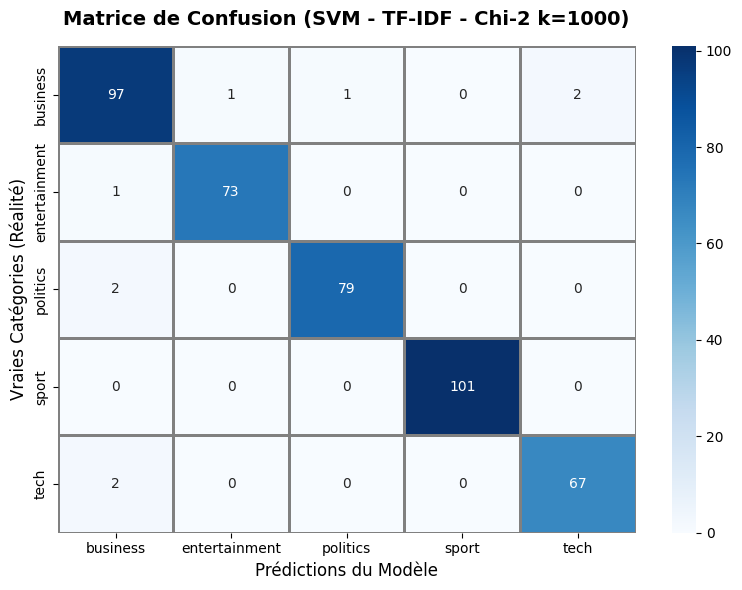

In [ ]:

# ==========================================
# 1. EXTRACTION AUTOMATIQUE DU MEILLEUR MODÈLE DEPUIS df_bloc1
# ==========================================
print(" Recherche automatique de la meilleure combinaison dans df_bloc1...")

# On récupère la ligne qui a la meilleure Accuracy
meilleure_ligne = df_bloc1.sort_values(by='Accuracy', ascending=False).iloc[0]

best_modele = meilleure_ligne['Modèle']
best_vect = meilleure_ligne['Vect']
best_sel = meilleure_ligne['Sélection']
best_k = int(meilleure_ligne['Taille'])

print(f" Le grand gagnant est : {best_modele} avec {best_vect} et {best_sel} (k={best_k}) ! Score : {meilleure_ligne['Accuracy']*100:.2f}%\n")

# ==========================================
# 2. RECALCUL RAPIDE DU GAGNANT POUR AVOIR SA MATRICE
# ==========================================
print(" Recalcul de cette unique combinaison pour générer la matrice...")

# A. Choix de la bonne matrice de base
X_train_rep = X_train_bow if best_vect == 'BoW' else X_train_tfidf
X_test_rep = X_test_bow if best_vect == 'BoW' else X_test_tfidf

# B. Choix du bon sélecteur
if best_sel == 'Chi-2':
    X_train_final, X_test_final, _ = select_chi2(X_train_rep, y_train, X_test_rep, k=best_k)
elif best_sel == 'Mutual Info':
    X_train_final, X_test_final, _ = select_mutual_info(X_train_rep, y_train, X_test_rep, k=best_k)
else: # LDA
    X_train_final, X_test_final, _ = apply_lda(X_train_rep, X_test_rep, n_components=best_k)

# C. Entraînement du bon modèle
if best_modele == 'SVM':
    _, best_res = run_svm(X_train_final, y_train, X_test_final, y_test)
elif best_modele == 'Naive Bayes':
    _, best_res = run_naive_bayes(X_train_final, y_train, X_test_final, y_test)
else: # AdaBoost
    _, best_res = run_adaboost(X_train_final, y_train, X_test_final, y_test)

# ==========================================
# 3. AFFICHAGE DE LA MATRICE DE CONFUSION
# ==========================================
noms_categories = np.unique(y_test) # Récupère les noms des classes (Business, Sport...)

plot_matrice_confusion(
    cm=best_res['confusion_matrix'],
    classes=noms_categories,
    titre=f"Matrice de Confusion ({best_modele} - {best_vect} - {best_sel} k={best_k})",
    nom_fichier="matrice_gagnant_bloc1.png"
)

## 8. BLOC 2 : Modèles Classiques sur Embeddings Denses
Nous abandonnons ici la représentation creuse au profit d'embeddings denses. Ces vecteurs capturent la sémantique et le contexte des mots de manière dense, éliminant ainsi le besoin de sélection de caractéristiques (Chi-2/MI).
* Génération des vecteurs **Word2Vec** (moyennés sur les documents).
* Génération des embeddings contextuels **BERT**.
* Entraînement de SVM et AdaBoost sur ces nouvelles matrices.

In [ ]:


print(" Lancement du Bloc 2 : ML Classique sur Embeddings Denses (Word2Vec & BERT)...\n")

# ==========================================
# 1. PRÉPARATION DES MATRICES DENSES
# ==========================================
print(" Génération des vecteurs Word2Vec en cours...")
X_train_w2v, model_w2v = apply_word2vec(X_train_text, vector_size=300)

# Application de Word2Vec sur le Test (avec le vocabulaire du Train)
test_tokens = [text.split() for text in X_test_text]
X_test_w2v = []
for tokens in test_tokens:
    word_vectors = [model_w2v.wv[w] for w in tokens if w in model_w2v.wv]
    if word_vectors:
        X_test_w2v.append(np.mean(word_vectors, axis=0))
    else:
        X_test_w2v.append(np.zeros(100))
X_test_w2v = np.array(X_test_w2v)

print(" Génération des embeddings BERT en cours (cela peut prendre un instant)...")
X_train_bert, model_bert = apply_bert(X_train_text)
X_test_bert = model_bert.encode(X_test_text.tolist(), show_progress_bar=False)

# ==========================================
# 2. ENTRAÎNEMENT DES MODÈLES (SVM & AdaBoost)
# ==========================================
matrices_denses = {
    'Word2Vec': (X_train_w2v, X_test_w2v),
    'BERT': (X_train_bert, X_test_bert)
}

resultats_bloc2 = []

for nom_rep, (X_train_rep, X_test_rep) in matrices_denses.items():
    print(f"\n=================== Représentation : {nom_rep} ===================")

    # Modèle 1 : SVM
    print(f"Entraînement de SVM sur {nom_rep}...")
    _, res_svm = run_svm(X_train_rep, y_train, X_test_rep, y_test)
    resultats_bloc2.append({
        'Modèle': 'SVM', 'Vect': nom_rep, 'Sélection': 'Aucune', 'Taille': 'Toutes',
        'Accuracy': res_svm['accuracy'],
        'Precision': res_svm['precision'],
        'Recall': res_svm['recall'],
        'F1 Macro': res_svm['f1_macro'],
        'Temps (s)': res_svm['training_time']
    })

    # Modèle 2 : AdaBoost
    print(f"Entraînement de AdaBoost sur {nom_rep}...")
    _, res_ada = run_adaboost(X_train_rep, y_train, X_test_rep, y_test)
    resultats_bloc2.append({
        'Modèle': 'AdaBoost', 'Vect': nom_rep, 'Sélection': 'Aucune', 'Taille': 'Toutes',
        'Accuracy': res_ada['accuracy'],
        'Precision': res_ada['precision'],
        'Recall': res_ada['recall'],
        'F1 Macro': res_ada['f1_macro'],
        'Temps (s)': res_ada['training_time']
    })

print("\n Bloc 2 terminé avec succès !")

# ==========================================
# 3. AFFICHAGE DU TABLEAU COMPLET
# ==========================================
df_bloc2 = pd.DataFrame(resultats_bloc2)

# On arrondit toutes les métriques pour que ça soit propre dans ton rapport
df_bloc2['Accuracy'] = df_bloc2['Accuracy'].round(4)
df_bloc2['Precision'] = df_bloc2['Precision'].round(4)
df_bloc2['Recall'] = df_bloc2['Recall'].round(4)
df_bloc2['F1 Macro'] = df_bloc2['F1 Macro'].round(4)
df_bloc2['Temps (s)'] = df_bloc2['Temps (s)'].round(4)

display(df_bloc2)

 Lancement du Bloc 2 : ML Classique sur Embeddings Denses (Word2Vec & BERT)...

 Génération des vecteurs Word2Vec en cours...
 Génération des embeddings BERT en cours (cela peut prendre un instant)...
Chargement du modèle BERT (all-MiniLM-L6-v2)... Cela peut prendre quelques secondes.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encodage des textes avec BERT en cours...


Batches:   0%|          | 0/54 [00:00<?, ?it/s]


=================== Représentation : Word2Vec ===================
Entraînement de SVM sur Word2Vec...
Entraînement de AdaBoost sur Word2Vec...

=================== Représentation : BERT ===================
Entraînement de SVM sur BERT...
Entraînement de AdaBoost sur BERT...

 Bloc 2 terminé avec succès !


,Modèle,Vect,Sélection,Taille,Accuracy,Precision,Recall,F1 Macro,Temps (s)
0,SVM,Word2Vec,Aucune,Toutes,0.8099,0.8203,0.7963,0.8025,0.2857
1,AdaBoost,Word2Vec,Aucune,Toutes,0.8920,0.8959,0.8860,0.8900,16.1676
2,SVM,BERT,Aucune,Toutes,0.9789,0.9795,0.9766,0.9780,0.1256
3,AdaBoost,BERT,Aucune,Toutes,0.9390,0.9373,0.9331,0.9348,21.4471


#  Analyse des Erreurs : Matrices de Confusion du bloc 2


 Recherche automatique du gagnant dans le BLOC 2 (Embeddings Denses)...
 Le grand gagnant du Bloc 2 est : SVM avec BERT ! Score : 97.89%
 Entraînement rapide du SVM pour récupérer sa matrice...

 Image sauvegardée avec succès sous le nom : matrice_gagnant_bloc2.png


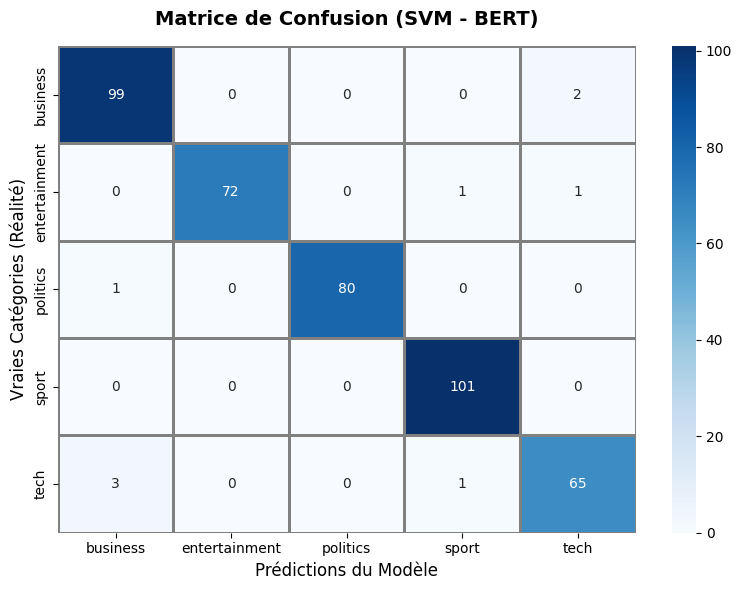

In [ ]:

# ==========================================
# EXTRACTION AUTOMATIQUE DU GAGNANT - BLOC 2
# ==========================================
print("\n Recherche automatique du gagnant dans le BLOC 2 (Embeddings Denses)...")

# 1. Trouver la meilleure ligne
meilleure_ligne_b2 = df_bloc2.sort_values(by='Accuracy', ascending=False).iloc[0]
best_modele_b2 = meilleure_ligne_b2['Modèle']
best_vect_b2 = meilleure_ligne_b2['Vect']

print(f" Le grand gagnant du Bloc 2 est : {best_modele_b2} avec {best_vect_b2} ! Score : {meilleure_ligne_b2['Accuracy']*100:.2f}%")

# 2. Récupérer les bonnes matrices (déjà calculées dans le Bloc 2)
X_train_rep_b2 = X_train_w2v if best_vect_b2 == 'Word2Vec' else X_train_bert
X_test_rep_b2 = X_test_w2v if best_vect_b2 == 'Word2Vec' else X_test_bert

# 3. Recalculer uniquement ce modèle
print(f" Entraînement rapide du {best_modele_b2} pour récupérer sa matrice...")
if best_modele_b2 == 'SVM':
    _, best_res_b2 = run_svm(X_train_rep_b2, y_train, X_test_rep_b2, y_test)
else:
    _, best_res_b2 = run_adaboost(X_train_rep_b2, y_train, X_test_rep_b2, y_test)

# 4. Tracer et sauvegarder
plot_matrice_confusion(
    cm=best_res_b2['confusion_matrix'],
    classes=np.unique(y_test),
    titre=f"Matrice de Confusion ({best_modele_b2} - {best_vect_b2})",
    nom_fichier="matrice_gagnant_bloc2.png"
)

## 9. preparation pour l'entrainemt du model
####Tokenize le texte
####applique le padding
####encode les catégories en nombres
####*Définition* des Architectures (CNN et LSTM)

In [ ]:


def prepare_dl_data(X_train_text, X_test_text, y_train, y_test, max_words=5000, max_len=200):
    """
    Tokenize le texte, applique le padding et encode les catégories en nombres.
    """
    # 1. Tokenization (Création du dictionnaire)
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(X_train_text)

    # 2. Transformation en séquences de nombres et Padding
    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len)
    X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=max_len)

    # 3. Encodage des labels (Ex: 'tech' -> 0, 'business' -> 1)
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_test_enc = label_encoder.transform(y_test)

    return X_train_seq, X_test_seq, y_train_enc, y_test_enc, len(tokenizer.word_index) + 1, len(label_encoder.classes_)

def train_evaluate_dl(model, X_train, y_train, X_test, y_test, epochs=5, batch_size=32):
    """
    Entraîne un modèle Keras, chronomètre et évalue les performances.
    """
    start_time = time.time()

    # Entraînement du modèle (verbose=1 pour voir la barre de progression)
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

    training_time = time.time() - start_time

    # Prédictions (Keras retourne des probabilités, on prend la classe max)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Évaluation via ta fonction générique !
    metrics = evaluate_performance(y_test, y_pred, training_time)

    return model, metrics

# ==========================================
# Définition des Architectures (CNN et LSTM)
# ==========================================

def run_cnn(X_train, y_train, X_test, y_test, vocab_size, num_classes, max_len=200):
    """Architecture CNN pour la classification de texte"""
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return train_evaluate_dl(model, X_train, y_train, X_test, y_test)

def run_lstm(X_train, y_train, X_test, y_test, vocab_size, num_classes, max_len=200):
    """Architecture LSTM pour la classification de texte"""
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len),
        # On utilise un petit LSTM pour que ça ne prenne pas des heures à tourner
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return train_evaluate_dl(model, X_train, y_train, X_test, y_test)

## 10. BLOC 3 : Apprentissage Profond (Deep Learning)
Pour cette dernière expérimentation, nous exploitons des architectures neuronales capables de traiter la séquentialité du texte. Le texte est d'abord "tokenisé" et "paddé" pour uniformiser la longueur des séquences.
* **CNN 1D :** Pour capturer les motifs locaux et les n-grammes de mots.
* **LSTM :** Pour conserver la mémoire contextuelle à long terme.

In [ ]:
print(" Lancement du Bloc 3 : Deep Learning (CNN & LSTM) avec toutes les métriques...\n")

# ==========================================
# 1. PRÉPARATION DES DONNÉES (Tokenization et Padding)
# ==========================================
# On fixe la longueur maximale des phrases
MAX_LEN = 200

print(" Préparation des séquences (Tokenization et Padding)...")
X_train_seq, X_test_seq, y_train_enc, y_test_enc, vocab_size, num_classes = prepare_dl_data(
    X_train_text, X_test_text, y_train, y_test, max_words=5000, max_len=MAX_LEN
)

print(f" Données prêtes ! Taille du vocabulaire : {vocab_size} | Nombre de classes : {num_classes}")

resultats_bloc3 = []

# ==========================================
# 2. ENTRAÎNEMENT DU CNN
# ==========================================
print("\n=================== Modèle : CNN ===================")
modele_cnn, res_cnn = run_cnn(X_train_seq, y_train_enc, X_test_seq, y_test_enc, vocab_size, num_classes, max_len=MAX_LEN)

resultats_bloc3.append({
    'Modèle': 'CNN', 'Vect': 'Embedding Keras', 'Sélection': 'Aucune', 'Taille': 'Max 200 mots',
    'Accuracy': res_cnn['accuracy'],
    'Precision': res_cnn['precision'], # <-- AJOUT
    'Recall': res_cnn['recall'],       # <-- AJOUT
    'F1 Macro': res_cnn['f1_macro'],
    'Temps (s)': res_cnn['training_time']
})

# ==========================================
# 3. ENTRAÎNEMENT DU LSTM
# ==========================================
print("\n=================== Modèle : LSTM ===================")
modele_lstm, res_lstm = run_lstm(X_train_seq, y_train_enc, X_test_seq, y_test_enc, vocab_size, num_classes, max_len=MAX_LEN)

resultats_bloc3.append({
    'Modèle': 'LSTM', 'Vect': 'Embedding Keras', 'Sélection': 'Aucune', 'Taille': 'Max 200 mots',
    'Accuracy': res_lstm['accuracy'],
    'Precision': res_lstm['precision'], # <-- AJOUT
    'Recall': res_lstm['recall'],       # <-- AJOUT
    'F1 Macro': res_lstm['f1_macro'],
    'Temps (s)': res_lstm['training_time']
})

print("\n Bloc 3 terminé avec succès !")

# ==========================================
# 4. AFFICHAGE DU TABLEAU COMPLET
# ==========================================
df_bloc3 = pd.DataFrame(resultats_bloc3)

# Arrondir toutes les métriques pour le rapport
df_bloc3['Accuracy'] = df_bloc3['Accuracy'].round(4)
df_bloc3['Precision'] = df_bloc3['Precision'].round(4)
df_bloc3['Recall'] = df_bloc3['Recall'].round(4)
df_bloc3['F1 Macro'] = df_bloc3['F1 Macro'].round(4)
df_bloc3['Temps (s)'] = df_bloc3['Temps (s)'].round(4)

display(df_bloc3)

 Lancement du Bloc 3 : Deep Learning (CNN & LSTM) avec toutes les métriques...

 Préparation des séquences (Tokenization et Padding)...
 Données prêtes ! Taille du vocabulaire : 25261 | Nombre de classes : 5

=================== Modèle : CNN ===================
Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.2712 - loss: 1.5840 - val_accuracy: 0.2235 - val_loss: 1.5507
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.5176 - loss: 1.3485 - val_accuracy: 0.7294 - val_loss: 1.0895
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.8333 - loss: 0.6572 - val_accuracy: 0.9118 - val_loss: 0.3718
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9431 - loss: 0.2365 - val_accuracy: 0.9588 - val_loss: 0.1647
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9876 - loss: 0.0854 - val_accuracy: 0.9529 - val_loss: 0.1399
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

=================== Modèle : LSTM ===================
Epoch 1/5
48

,Modèle,Vect,Sélection,Taille,Accuracy,Precision,Recall,F1 Macro,Temps (s)
0,CNN,Embedding Keras,Aucune,Max 200 mots,0.9554,0.9601,0.9507,0.9543,25.263
1,LSTM,Embedding Keras,Aucune,Max 200 mots,0.9014,0.9029,0.8921,0.8954,48.227


#  Analyse des Erreurs : Matrices de Confusion du bloc 3


Recherche automatique du gagnant dans le BLOC 3 (Deep Learning)...
 Le grand gagnant du Bloc 3 est : LSTM ! Score : 90.14%
 Entraînement du réseau LSTM (Patiente un instant...)
Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - accuracy: 0.3392 - loss: 1.4996 - val_accuracy: 0.4412 - val_loss: 1.0883
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.5516 - loss: 0.9918 - val_accuracy: 0.6412 - val_loss: 0.8197
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.6824 - loss: 0.7429 - val_accuracy: 0.8647 - val_loss: 0.5851
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.8444 - loss: 0.4930 - val_accuracy: 0.8588 - val_loss: 0.4422
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.9425 - loss: 0.2323 - val_accuracy: 0.9059 - val_loss: 0.3402
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

 Image sauvegardée avec succès sous le nom : matrice_gagnant_bloc3.png


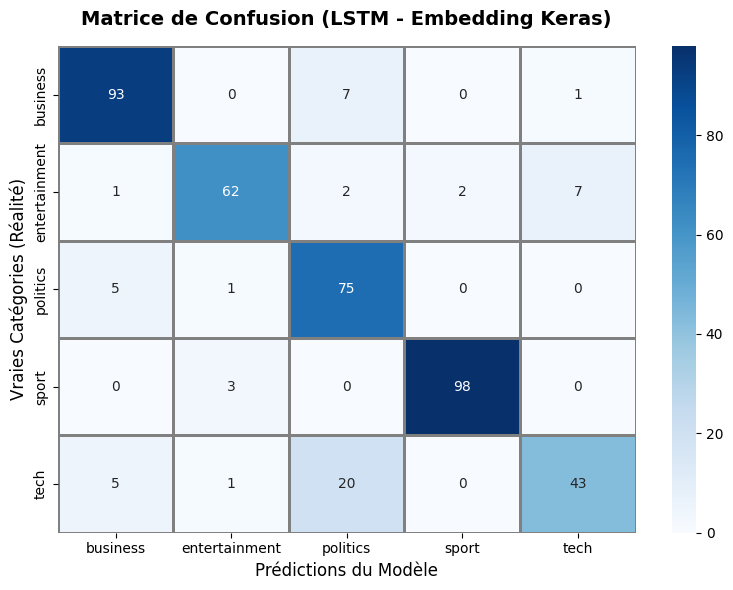

In [ ]:
# ==========================================
# EXTRACTION AUTOMATIQUE DU GAGNANT - BLOC 3
# ==========================================
print("\nRecherche automatique du gagnant dans le BLOC 3 (Deep Learning)...")

# 1. Trouver la meilleure ligne
meilleure_ligne_b3 = df_bloc3.sort_values(by='Accuracy', ascending=True ).iloc[0]
best_modele_b3 = meilleure_ligne_b3['Modèle']

print(f" Le grand gagnant du Bloc 3 est : {best_modele_b3} ! Score : {meilleure_ligne_b3['Accuracy']*100:.2f}%")

# 2. Recalculer le meilleur réseau de neurones
print(f" Entraînement du réseau {best_modele_b3} (Patiente un instant...)")
if best_modele_b3 == 'CNN':
    _, best_res_b3 = run_cnn(X_train_seq, y_train_enc, X_test_seq, y_test_enc, vocab_size, num_classes, max_len=MAX_LEN)
else:
    _, best_res_b3 = run_lstm(X_train_seq, y_train_enc, X_test_seq, y_test_enc, vocab_size, num_classes, max_len=MAX_LEN)

# 3. Tracer et sauvegarder (Attention ici, Deep Learning donne parfois des index, on utilise les noms)
plot_matrice_confusion(
    cm=best_res_b3['confusion_matrix'],
    classes=np.unique(y_test),
    titre=f"Matrice de Confusion ({best_modele_b3} - Embedding Keras)",
    nom_fichier="matrice_gagnant_bloc3.png"
)